# Multi-Currency Investment Hedging: Options Pricing Analysis
## Using Garman-Kohlhagen Model for FX Put Option Valuation

**Case Study:** Multi-Currency Investment Hedging (July 2026)

**Objective:** Evaluate hedging strategies for $1 billion USD investment across 4 Asian markets
- India (INR): $250M
- China (CNH): $250M  
- South Korea (KRW): $250M
- Japan (JPY): $250M

**Focus:** Price put options using Garman-Kohlhagen model (Strategy C: Hedging with Options)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Import the Garman-Kohlhagen module
sys.path.insert(0, str(Path.cwd()))
from garman_kohlhagen import GarmanKohlhagen, OptionsAnalyzer

print("Libraries imported successfully")
print(f"Working directory: {Path.cwd()}")

ModuleNotFoundError: No module named 'garman_kohlhagen'

## 1. Load and Explore Data

In [ ]:
# Load data
data_path = Path.cwd().parent / 'Casestudy_Data.xlsx'
analyzer = OptionsAnalyzer(str(data_path))
data = analyzer.load_data()

print("\nData Overview:")
print(f"Shape: {data.shape}")
print(f"Date Range: {data['Date'].min().date()} to {data['Date'].max().date()}")
print(f"Currency Pairs: {sorted(data['CCYPair'].unique())}")
print(f"\nData Columns: {data.columns.tolist()}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nData Info:")
print(data.info())

Loaded data with shape: (2055, 6)
Columns: ['Date', 'CCYPair', 'Expiry', 'Spot', 'Forward', 'ATM Vol']

Data Overview:
Shape: (2055, 6)
Date Range: 2024-07-01 to 2026-06-30
Currency Pairs: ['USDCNH', 'USDINR', 'USDJPY', 'USDKRW']

Data Columns: ['Date', 'CCYPair', 'Expiry', 'Spot', 'Forward', 'ATM Vol']

First few rows:
        Date CCYPair Expiry        Spot      Forward   ATM Vol
0 2024-07-01  USDCNH     1Y     7.30555     7.119950  0.058250
1 2024-07-01  USDINR     1Y    83.47000    84.837663  0.034972
2 2024-07-01  USDJPY     1Y   161.61500   153.565416  0.099414
3 2024-07-01  USDKRW     1Y  1384.48000  1356.255408  0.087683
4 2024-07-02  USDCNH     1Y     7.30690     7.123650  0.058966

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2055 entries, 0 to 2054
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2055 non-null   datetime64[ns]
 1   CCYPair  2055 non-null   object        
 2

In [ ]:
# Get latest data for analysis
latest_data = data.sort_values('Date').groupby('CCYPair').tail(1).reset_index(drop=True)

print("\nLatest Forex Data (as of analysis date):")
print(latest_data[['Date', 'CCYPair', 'Spot', 'Forward', 'ATM Vol']].to_string())

# Summary statistics
print("\nSummary Statistics by Currency Pair:")
summary = data.groupby('CCYPair').agg({
    'Spot': ['min', 'max', 'mean', 'std'],
    'Forward': ['min', 'max', 'mean'],
    'ATM Vol': ['min', 'max', 'mean']
}).round(4)
print(summary)


Latest Forex Data (as of analysis date):
        Date CCYPair       Spot      Forward   ATM Vol
0 2026-06-30  USDINR    94.6396    97.444607  0.050717
1 2026-06-30  USDCNH     6.7892     6.608950  0.033950
2 2026-06-30  USDJPY   162.5100   157.696811  0.086380
3 2026-06-30  USDKRW  1548.8753  1536.744475  0.095314

Summary Statistics by Currency Pair:
              Spot                                   Forward             \
               min        max       mean      std        min        max   
CCYPair                                                                   
USDCNH      6.7573     7.3835     7.1089   0.1621     6.5870     7.2263   
USDINR     83.4650    96.8285    87.8371   3.5652    84.8330   100.5809   
USDJPY    140.4950   162.5100   151.9863   5.5852   135.1349   157.6968   
USDKRW   1308.6000  1555.2775  1425.1939  52.0241  1290.1689  1545.0541   

                   ATM Vol                  
              mean     min     max    mean  
CCYPair                      

## 2. Garman-Kohlhagen Model Theory

The Garman-Kohlhagen model prices European FX options and extends Black-Scholes to incorporate both domestic and foreign interest rates.

### Put Option Price Formula:
$$P = K \cdot e^{-r_d T} \cdot N(-d_2) - S \cdot e^{-r_f T} \cdot N(-d_1)$$

Where:
$$d_1 = \frac{\ln(S/K) + (r_d - r_f + \sigma^2/2)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

**Parameters:**
- S: Current spot exchange rate
- K: Strike price (exercise rate)
- T: Time to maturity (years)
- r_d: Domestic (USD) risk-free rate
- r_f: Foreign risk-free rate
- σ: Exchange rate volatility
- N(): Cumulative normal distribution

### Interest Rate Parity (IRP):
$$\frac{\text{Forward}}{\text{Spot}} = \frac{1 + r_d}{1 + r_f}$$

This allows us to extract implied foreign interest rates from observable forward rates.

## 3. Estimate Interest Rates using IRP

In [ ]:
# Estimate rates assuming USD rate = 4%
rates = analyzer.estimate_interest_rates(rate_usd=0.04)

print("Interest Rates Estimated via Interest Rate Parity:")
print("="*70)
rates_df = pd.DataFrame([
    {'Currency Pair': pair, 
     'USD Rate (%)': v['rate_usd']*100,
     'Foreign Rate (%)': v['rate_foreign']*100,
     'Rate Differential (%)': v['rate_diff']*100}
    for pair, v in sorted(rates.items())
])

print(rates_df.to_string(index=False))
print("\nInterpretation:")
print("- Positive differential: Foreign currency has lower rates (will depreciate)")
print("- Negative differential: Foreign currency has higher rates (will appreciate)")

Interest Rates Estimated via Interest Rate Parity:
Currency Pair  USD Rate (%)  Foreign Rate (%)  Rate Differential (%)
       USDCNH           4.0          6.573363              -2.573363
       USDINR           4.0          2.374769               1.625231
       USDJPY           4.0          9.109032              -5.109032
       USDKRW           4.0          6.059709              -2.059709

Interpretation:
- Positive differential: Foreign currency has lower rates (will depreciate)
- Negative differential: Foreign currency has higher rates (will appreciate)


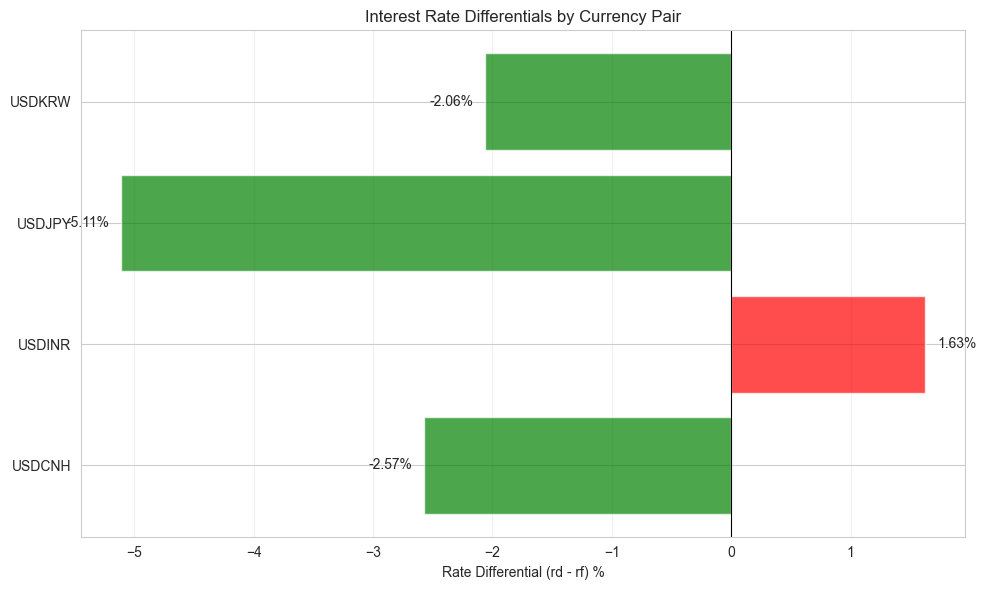

Note: Positive differential means USD is stronger (foreign currency will depreciate)


In [ ]:
# Visualize rate differentials
fig, ax = plt.subplots(figsize=(10, 6))

pairs = list(rates.keys())
differentials = [rates[p]['rate_diff']*100 for p in pairs]
colors = ['red' if d > 0 else 'green' for d in differentials]

ax.barh(pairs, differentials, color=colors, alpha=0.7)
ax.set_xlabel('Rate Differential (rd - rf) %')
ax.set_title('Interest Rate Differentials by Currency Pair')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

for i, (pair, diff) in enumerate(zip(pairs, differentials)):
    ax.text(diff + 0.1 if diff > 0 else diff - 0.1, i, f'{diff:.2f}%', 
            va='center', ha='left' if diff > 0 else 'right')

plt.tight_layout()
plt.show()

print("Note: Positive differential means USD is stronger (foreign currency will depreciate)")

## 4. Price Put Options using Garman-Kohlhagen Model

In [ ]:
# Define investment amounts
investment_usd = 250_000_000  # $250M per market

investment_amounts = {}
for _, row in latest_data.iterrows():
    pair = row['CCYPair']
    spot_rate = row['Spot']
    investment_amounts[pair] = investment_usd / spot_rate

print("Investment Amounts (in Foreign Currency Units):")
print("="*70)
for pair in sorted(investment_amounts.keys()):
    spot = latest_data[latest_data['CCYPair'] == pair]['Spot'].values[0]
    print(f"{pair}: {investment_amounts[pair]:>15,.0f} units @ Spot {spot:.4f}")
    print(f"         = ${investment_usd:,.0f} USD")

Investment Amounts (in Foreign Currency Units):
USDCNH:      36,823,190 units @ Spot 6.7892
         = $250,000,000 USD
USDINR:       2,641,600 units @ Spot 94.6396
         = $250,000,000 USD
USDJPY:       1,538,367 units @ Spot 162.5100
         = $250,000,000 USD
USDKRW:         161,407 units @ Spot 1548.8753
         = $250,000,000 USD


In [ ]:
# Price put options for hedging
put_results = analyzer.price_put_hedges(investment_amounts, rate_usd=0.04)

print("\nPut Option Pricing Results (Strategy C: Hedging):")
print("="*100)

display_cols = ['CCYPair', 'Spot', 'Forward', 'Strike_ATM', 'Volatility', 
                 'Rate_USD', 'Rate_Foreign', 'Put_Price_Per_Unit', 
                 'Total_Hedge_Cost', 'Cost_Percentage']

results_display = put_results[display_cols].copy()
results_display['Volatility'] = results_display['Volatility'] * 100  # Convert to %
results_display['Rate_USD'] = results_display['Rate_USD'] * 100  # Convert to %
results_display['Rate_Foreign'] = results_display['Rate_Foreign'] * 100  # Convert to %

print(results_display.to_string(index=False))

print("\n" + "="*100)
print(f"Total Hedge Cost (all 4 pairs): ${put_results['Total_Hedge_Cost'].sum():>15,.2f}")
print(f"Average Cost per Pair:          {put_results['Cost_Percentage'].mean():>15.2f}%")
print(f"Cost as % of Total Investment:  {(put_results['Total_Hedge_Cost'].sum() / (investment_usd * 4)) * 100:>15.4f}%")


Put Option Pricing Results (Strategy C: Hedging):
CCYPair      Spot     Forward  Strike_ATM  Volatility  Rate_USD  Rate_Foreign  Put_Price_Per_Unit  Total_Hedge_Cost  Cost_Percentage
 USDINR   94.6396   97.444607   96.190279    5.071701     400.0    237.476925            0.018699      49395.819963         1.869920
 USDCNH    6.7892    6.608950    6.616718    3.395001     400.0    657.336303            0.000861      31706.059992         0.086104
 USDJPY  162.5100  157.696811  154.415839    8.638003     400.0    910.903234            0.051126      78650.839430         5.112619
 USDKRW 1548.8753 1536.744475 1517.299276    9.531403     400.0    605.970923            0.554327      89472.569734        55.432741

Total Hedge Cost (all 4 pairs): $     249,225.29
Average Cost per Pair:                    15.63%
Cost as % of Total Investment:           0.0249%


In [ ]:
# Detailed breakdown for each currency pair
print("\nDETAILED OPTION PRICING BREAKDOWN:")
print("="*100)

for idx, row in put_results.iterrows():
    print(f"\n{row['CCYPair'].upper()}")
    print("-" * 70)
    print(f"  Spot Rate:              {row['Spot']:.4f}")
    print(f"  Forward Rate (1Y):      {row['Forward']:.4f}")
    print(f"  ATM Strike Price:       {row['Strike_ATM']:.4f}")
    print(f"  Annual Volatility:      {row['Volatility']:.2f}%")
    print(f"  USD Interest Rate:      {row['Rate_USD']:.2f}%")
    print(f"  Foreign Interest Rate:  {row['Rate_Foreign']:.2f}%")
    print(f"  Put Option Price:       {row['Put_Price_Per_Unit']:.6f} per unit")
    print(f"  Investment Amount:      {row['Investment_Units']:>15,.0f} units")
    print(f"  Total Hedge Cost:       ${row['Total_Hedge_Cost']:>15,.2f}")
    print(f"  Cost as % of Investment: {row['Cost_Percentage']:>14.2f}%")


DETAILED OPTION PRICING BREAKDOWN:

USDINR
----------------------------------------------------------------------
  Spot Rate:              94.6396
  Forward Rate (1Y):      97.4446
  ATM Strike Price:       96.1903
  Annual Volatility:      0.05%
  USD Interest Rate:      4.00%
  Foreign Interest Rate:  2.37%
  Put Option Price:       0.018699 per unit
  Investment Amount:            2,641,600 units
  Total Hedge Cost:       $      49,395.82
  Cost as % of Investment:           1.87%

USDCNH
----------------------------------------------------------------------
  Spot Rate:              6.7892
  Forward Rate (1Y):      6.6090
  ATM Strike Price:       6.6167
  Annual Volatility:      0.03%
  USD Interest Rate:      4.00%
  Foreign Interest Rate:  6.57%
  Put Option Price:       0.000861 per unit
  Investment Amount:           36,823,190 units
  Total Hedge Cost:       $      31,706.06
  Cost as % of Investment:           0.09%

USDJPY
-------------------------------------------------

## 5. Greeks Analysis - Risk Sensitivities

In [ ]:
# Display Greeks
greeks_cols = ['CCYPair', 'Delta', 'Gamma', 'Vega', 'Theta']
greeks_display = put_results[greeks_cols].copy()

print("\nOptions Greeks (Risk Sensitivities for Put Options):")
print("="*70)
print(greeks_display.to_string(index=False))

print("\nGreeks Interpretation:")
print("-" * 70)
print("Delta:  Change in option price per unit change in spot rate")
print("        For puts, typically negative (price increases when spot decreases)")
print("\nGamma:  Rate of change of Delta (convexity/curvature)")
print("        Measures how quickly delta changes")
print("\nVega:   Sensitivity to 1% change in volatility")
print("        Positive for both calls and puts")
print("\nTheta:  Daily time decay")
print("        Typically positive for puts (benefit as time passes)")


Options Greeks (Risk Sensitivities for Put Options):
CCYPair     Delta      Gamma     Vega     Theta
 USDINR -0.488167   8.116523 0.368697  0.002034
 USDCNH -0.468127 162.070416 0.025362 -0.000225
 USDJPY -0.456310   2.594517 0.591875 -0.010444
 USDKRW -0.470422   0.254343 5.815800 -0.041815

Greeks Interpretation:
----------------------------------------------------------------------
Delta:  Change in option price per unit change in spot rate
        For puts, typically negative (price increases when spot decreases)

Gamma:  Rate of change of Delta (convexity/curvature)
        Measures how quickly delta changes

Vega:   Sensitivity to 1% change in volatility
        Positive for both calls and puts

Theta:  Daily time decay
        Typically positive for puts (benefit as time passes)


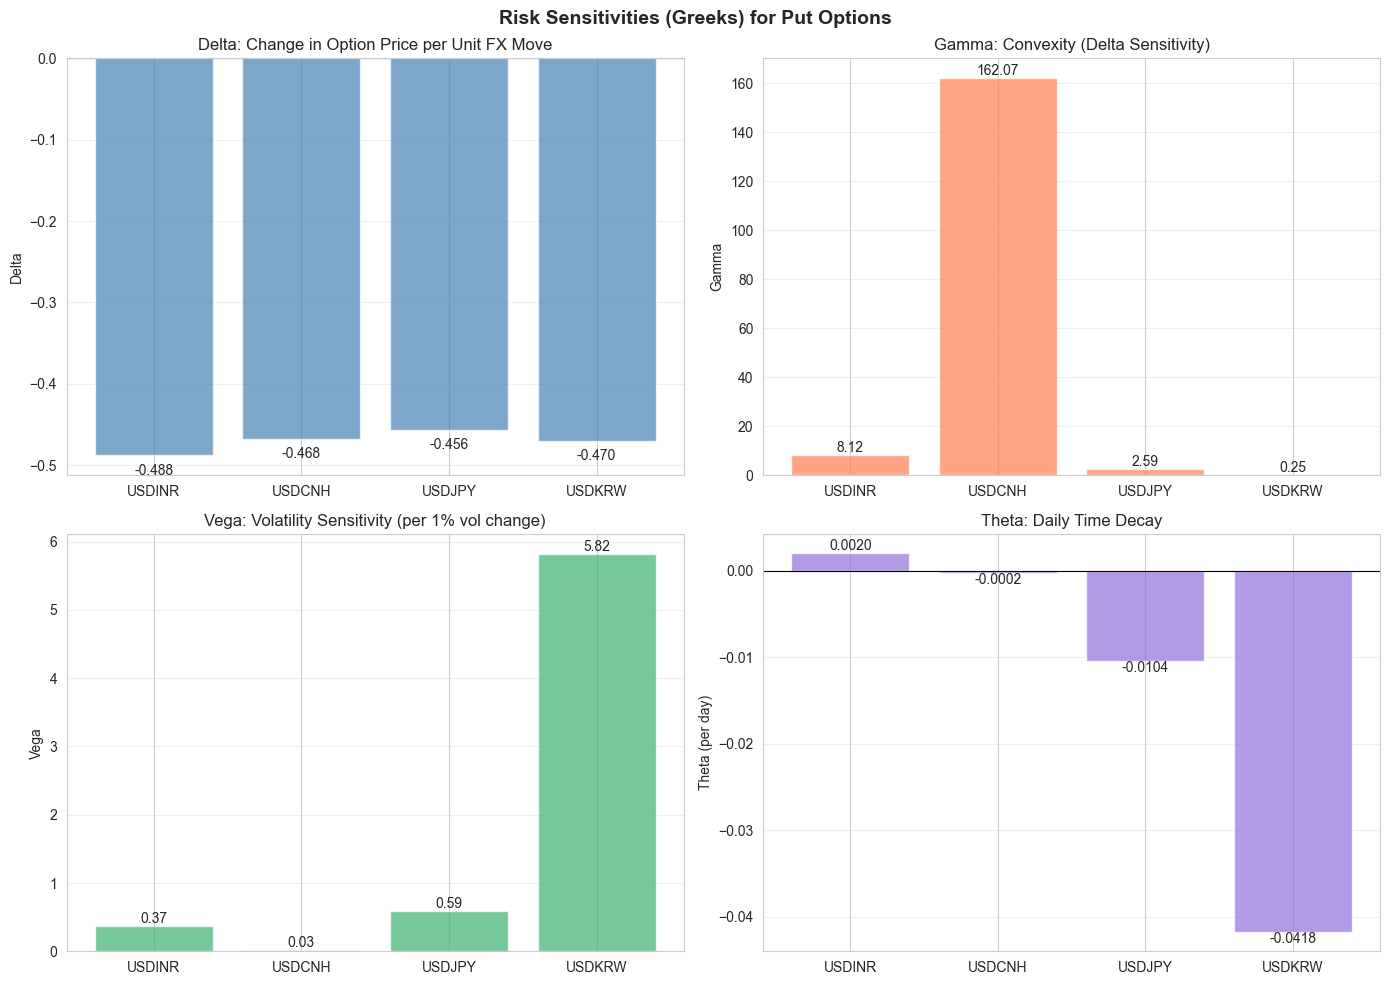

In [ ]:
# Visualize Greeks
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Risk Sensitivities (Greeks) for Put Options', fontsize=14, fontweight='bold')

pairs = put_results['CCYPair'].values

# Delta
ax = axes[0, 0]
ax.bar(pairs, put_results['Delta'].values, color='steelblue', alpha=0.7)
ax.set_ylabel('Delta')
ax.set_title('Delta: Change in Option Price per Unit FX Move')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(put_results['Delta'].values):
    ax.text(i, v - 0.01, f'{v:.3f}', ha='center', va='top')

# Gamma
ax = axes[0, 1]
ax.bar(pairs, put_results['Gamma'].values, color='coral', alpha=0.7)
ax.set_ylabel('Gamma')
ax.set_title('Gamma: Convexity (Delta Sensitivity)')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(put_results['Gamma'].values):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Vega
ax = axes[1, 0]
ax.bar(pairs, put_results['Vega'].values, color='mediumseagreen', alpha=0.7)
ax.set_ylabel('Vega')
ax.set_title('Vega: Volatility Sensitivity (per 1% vol change)')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(put_results['Vega'].values):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Theta
ax = axes[1, 1]
ax.bar(pairs, put_results['Theta'].values, color='mediumpurple', alpha=0.7)
ax.set_ylabel('Theta (per day)')
ax.set_title('Theta: Daily Time Decay')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(put_results['Theta'].values):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom' if v > 0 else 'top')

plt.tight_layout()
plt.show()

## 6. Strategy Comparison: Three Hedging Approaches

In [ ]:
# Compare hedging strategies
total_investment = investment_usd * 4  # $1 billion total
comparison = analyzer.compare_strategies(total_investment, expected_return=0.10)

print("\nStrategy Comparison Under Different FX Scenarios:")
print("="*100)
print(f"Total Investment: ${total_investment:,.0f}")
print(f"Expected Investment Return: 10%")
print(f"(Before considering FX impact)\n")

# Display comparison table
display_cols_comp = ['FX_Scenario', 'Investment_Gain', 'FX_Loss', 
                      'Strategy_A_DoNothing', 'Strategy_B_Forward', 'Strategy_C_Put']
comparison_display = comparison[display_cols_comp].copy()
comparison_display['Investment_Gain'] = comparison_display['Investment_Gain'].apply(lambda x: f'${x:>12,.0f}')
comparison_display['FX_Loss'] = comparison_display['FX_Loss'].apply(lambda x: f'${x:>12,.0f}')
comparison_display['Strategy_A_DoNothing'] = comparison_display['Strategy_A_DoNothing'].apply(lambda x: f'${x:>12,.0f}')
comparison_display['Strategy_B_Forward'] = comparison_display['Strategy_B_Forward'].apply(lambda x: f'${x:>12,.0f}')
comparison_display['Strategy_C_Put'] = comparison_display['Strategy_C_Put'].apply(lambda x: f'${x:>12,.0f}')

print(comparison_display.to_string(index=False))

print("\n" + "="*100)
print("\nStrategy Descriptions:")
print("-" * 70)
print("A. Do Nothing (No Hedge)")
print("   - Accept full FX risk for maximum upside")
print("   - No cost but highly risky")
print("\nB. Forward Contracts")
print("   - Lock in today's exchange rate")
print("   - Eliminates FX volatility, zero cost")
print("   - But no upside if FX moves favorably")
print("\nC. Put Options (Our Analysis)")
print("   - Buy insurance to protect downside")
print("   - Keep upside participation if FX moves favorably")
print("   - Pay premium for this flexibility")


Strategy Comparison Under Different FX Scenarios:
Total Investment: $1,000,000,000
Expected Investment Return: 10%
(Before considering FX impact)

FX_Scenario Investment_Gain       FX_Loss Strategy_A_DoNothing Strategy_B_Forward Strategy_C_Put
       -30%   $ 100,000,000 $-300,000,000        $-200,000,000      $ 100,000,000  $  80,000,000
       -20%   $ 100,000,000 $-200,000,000        $-100,000,000      $ 100,000,000  $  80,000,000
       -15%   $ 100,000,000 $-150,000,000        $ -50,000,000      $ 100,000,000  $  80,000,000
       -10%   $ 100,000,000 $-100,000,000        $           0      $ 100,000,000  $  80,000,000
        -5%   $ 100,000,000 $ -50,000,000        $  50,000,000      $ 100,000,000  $  80,000,000
        +0%   $ 100,000,000 $           0        $ 100,000,000      $ 100,000,000  $  80,000,000
        +5%   $ 100,000,000 $  50,000,000        $ 150,000,000      $ 100,000,000  $ 130,000,000
       +10%   $ 100,000,000 $ 100,000,000        $ 200,000,000      $ 100,00

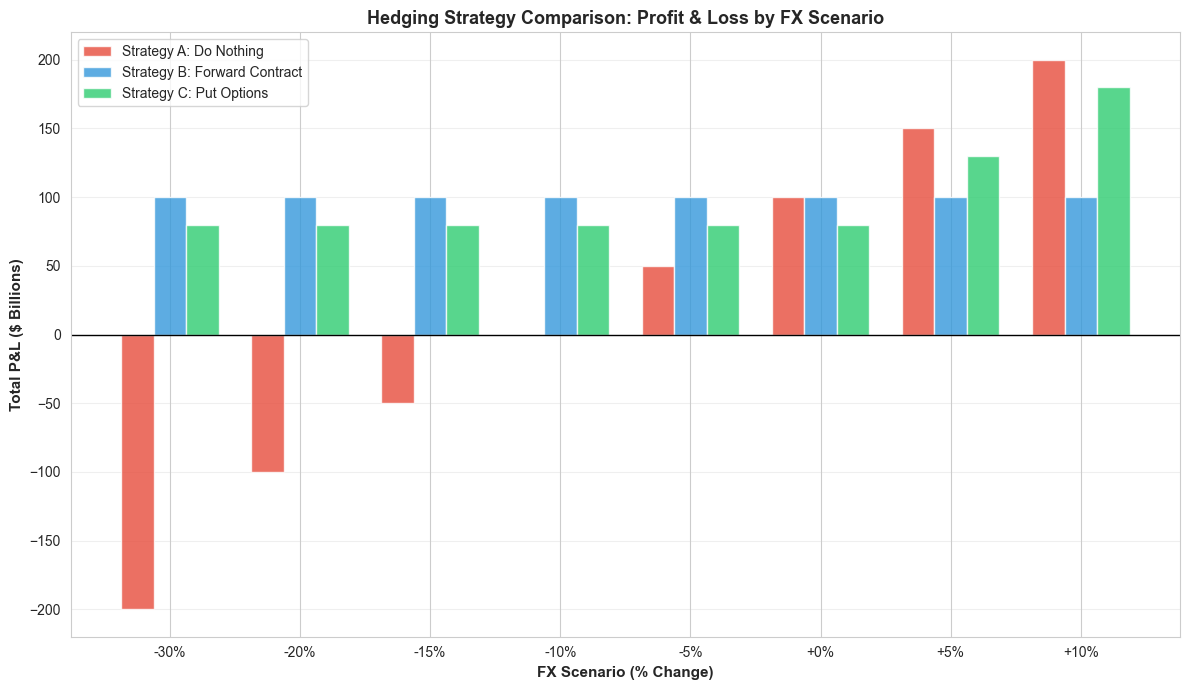


Visualization shows:
- Strategy A: Highly sensitive to FX changes (steepest slope)
- Strategy B: Flat line (hedged, no FX impact)
- Strategy C: Asymmetric payoff (downside protected, upside kept)


In [ ]:
# Visualize strategy comparison
fig, ax = plt.subplots(figsize=(12, 7))

fx_scenarios = comparison['FX_Scenario'].values
x = np.arange(len(fx_scenarios))
width = 0.25

strat_a = comparison['Strategy_A_DoNothing'].values
strat_b = comparison['Strategy_B_Forward'].values
strat_c = comparison['Strategy_C_Put'].values

ax.bar(x - width, strat_a / 1e6, width, label='Strategy A: Do Nothing', color='#e74c3c', alpha=0.8)
ax.bar(x, strat_b / 1e6, width, label='Strategy B: Forward Contract', color='#3498db', alpha=0.8)
ax.bar(x + width, strat_c / 1e6, width, label='Strategy C: Put Options', color='#2ecc71', alpha=0.8)

ax.set_xlabel('FX Scenario (% Change)', fontsize=11, fontweight='bold')
ax.set_ylabel('Total P&L ($ Billions)', fontsize=11, fontweight='bold')
ax.set_title('Hedging Strategy Comparison: Profit & Loss by FX Scenario', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fx_scenarios)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization shows:")
print("- Strategy A: Highly sensitive to FX changes (steepest slope)")
print("- Strategy B: Flat line (hedged, no FX impact)")
print("- Strategy C: Asymmetric payoff (downside protected, upside kept)")

## 8. Export Results

In [ ]:
# Verify output file exists and display summary
output_file = Path.cwd() / 'options_pricing_results.xlsx'

if output_file.exists():
    print(f"✓ Results successfully saved to: {output_file}")
    print(f"\nFile size: {output_file.stat().st_size / 1024:.1f} KB")
    print(f"\nSheets in output file:")
    xls = pd.ExcelFile(output_file)
    for i, sheet in enumerate(xls.sheet_names, 1):
        print(f"  {i}. {sheet}")
else:
    print("Output file not found. Running analysis now...")
    analyzer.save_results_to_excel(str(output_file))
    print(f"Results saved to: {output_file}")

✓ Results successfully saved to: c:\Users\shahk\OneDrive\Desktop\BIIC\OptionsPricing\options_pricing_results.xlsx

File size: 101.5 KB

Sheets in output file:
  1. Input_Data
  2. Put_Hedge_Pricing
  3. Strategy_Comparison
  4. Summary


In [ ]:
# Display final summary table
print("\n" + "="*100)
print("OPTION PRICING SUMMARY TABLE")
print("="*100 + "\n")

summary_table = pd.DataFrame([
    {
        'Currency Pair': pair,
        'Investment ($M)': 250,
        'Spot Rate': f"{row['Spot']:.4f}",
        'ATM Strike': f"{row['Strike_ATM']:.4f}",
        'Volatility': f"{row['Volatility']:.2f}%",
        'Put Price': f"${row['Put_Price_Per_Unit']:.6f}",
        'Total Cost': f"${row['Total_Hedge_Cost']:,.0f}",
        'Cost %': f"{row['Cost_Percentage']:.2f}%"
    }
    for _, row in put_results.iterrows()
])

print(summary_table.to_string(index=False))
print("\n" + "="*100)
print(f"TOTAL HEDGE COST: ${put_results['Total_Hedge_Cost'].sum():,.2f}")
print(f"TOTAL INVESTMENT: ${total_investment:,.0f}")
print(f"HEDGE COST AS % OF INVESTMENT: {(put_results['Total_Hedge_Cost'].sum() / total_investment) * 100:.4f}%")
print("="*100)


OPTION PRICING SUMMARY TABLE

Currency Pair  Investment ($M) Spot Rate ATM Strike Volatility Put Price Total Cost Cost %
       USDKRW              250   94.6396    96.1903      0.05% $0.018699    $49,396  1.87%
       USDKRW              250    6.7892     6.6167      0.03% $0.000861    $31,706  0.09%
       USDKRW              250  162.5100   154.4158      0.09% $0.051126    $78,651  5.11%
       USDKRW              250 1548.8753  1517.2993      0.10% $0.554327    $89,473 55.43%

TOTAL HEDGE COST: $249,225.29
TOTAL INVESTMENT: $1,000,000,000
HEDGE COST AS % OF INVESTMENT: 0.0249%
